In [10]:
# self-contained interactive tool

from dataclasses import dataclass
from scipy.optimize import minimize
import scipy.integrate as integrate
from itertools import combinations
import numpy as np

@dataclass
class Params:
    '''
    Configuration of two current loops
    '''
    x1: float = -1.0    # x-locations of loop centers at y=0
    x2: float =  1.0
    z1: float =  0.0    # z-heights of the loops
    z2: float = -0.01
    a1: float =  1.0    # radii of the loops
    a2: float =  2.0
    I_ratio: float = -1 # I2/I1
    def __str__(self): # make Parms object printable
        n = 4
        return \
        f'(x1,x2)=({round(self.x1,n)},{round(self.x2,n)}), ' + \
        f'(z1,z2)=({round(self.z1,n)},{round(self.z2,n)}), ' + \
        f'(a1,a2)=({round(self.a1,n)},{round(self.a2,n)}), ' + \
        f'I_ratio={round(self.I_ratio,n)}'

@dataclass
class ParamBounds:
    '''
    Acceptable (min, max) for each param above
    '''
    x1 = (-3, 3)
    x2 = (-3, 3)
    z1 = (-0.02, 0)
    z2 = (-0.02, 0)
    a1 = (0.5, 3)
    a2 = (0.5, 3)
    I_ratio = (-2, -0.5)

def dB(x, y, z, a, t):
    '''
    Magnetic field at (x, y, z) of infinitesimal piece of loop with unit current
    lying in (x,y) plane with the center at the origin and radius a.
    The loop is defined parametrically as x=a*cos(t), y=a*sin(t), z=0
    '''
    cos = np.cos(t)
    sin = np.sin(t)
    num = np.array([cos*z, sin*z, -sin*(y-a*sin) - cos*(x-a*cos)])
    den = (x-a*cos)**2 + (y-a*sin)**2 + z**2
    den *= np.sqrt(den)
    return num/den
    
def loop_B(x, y, z, a):
    '''
    Magnetic field of full loop -- t-integral of dB over the loop
    '''
    return integrate.quad_vec(lambda t: dB(x, y, z, a, t), 0, 2*np.pi)
    
def Bxz(x, z, x1, x2, z1, z2, a1, a2, I1, I2):
    '''
    Magnetic field in the plane y=0 of two current loops with centers
    at (x_i, 0, z_i), radii a_i, and currents I_i.
    z_i are small nonpositive distances down from the chip plane
    '''
    B1 = loop_B(x - x1, 0, z - z1, a1)[0]
    B2 = loop_B(x - x2, 0, z - z2, a2)[0]
    return np.array([I1*B1[0] + I2*B2[0], I1*B1[2] + I2*B2[2]])

def search_params(null_x, null_z, vars):
    '''
    Minimize square magnetic field at the given point (null_x, 0, null_x) starting with
    default Params and varying or more specified params while holding others constant.
    Variable param names are in the list vars, for example ['x1', 'x2']
    '''
    pp = Params()  # default/initial values
    bb = ParamBounds()
    def utility(values):
        '''
        Squared magnetic field at (null_x, 0, null_z)
        '''
        for var, value in zip(vars, values):
            setattr(pp, var, value) # set pp.<var> = value
        I1, I2 = 1, pp.I_ratio
        return np.sum(np.square(
            Bxz(null_z, null_z, pp.x1, pp.x2, pp.z1, pp.z2, pp.a1, pp.a2, I1, I2)
        ))
    initial_values = [getattr(pp, var) for var in vars] # extract default pp.<var> as initial guess
    bounds         = [getattr(bb, var) for var in vars] # extract default bounds for the variables
    result = minimize(utility, initial_values, bounds=bounds)
    return result # object containing results of optimization

In [11]:
# target point in cm for zero magnetic field:
null_x, null_z = np.array([0.0]), np.array([1.5])

# select various combinations of params to play with
dim = 3 # generate all distinct triplets - more success than with singles or pairs
vars_tuples = list(combinations(['x1', 'x2', 'z1', 'z2', 'a1', 'a2', 'I_ratio'], dim))
# print(vars_tuples) #  [('x1', 'x2', 'z1'), ('x1', 'x2', 'z2'), etc]

results = [] # for each vars_tuple
for vars in vars_tuples:
    result = search_params(null_x, null_z, vars)
    results.append(result)
    print(f'{vars} -> {result.x}: B2 -> {result.fun}')
    # review the output for next steps

('x1', 'x2', 'z1') -> [ 0.10230892 -0.54134753 -0.01301276]: B2 -> 9.402876341589802e-12
('x1', 'x2', 'z2') -> [ 0.07203917 -0.57845816 -0.00176047]: B2 -> 1.0589615947350779e-15
('x1', 'x2', 'a1') -> [-2.36213398 -1.62808156  2.95673524]: B2 -> 2.6805780565648405e-12
('x1', 'x2', 'a2') -> [ 0.03472516 -0.62992126  2.01204105]: B2 -> 6.7144986286049154e-12
('x1', 'x2', 'I_ratio') -> [-0.87815026 -1.50670226 -0.78251353]: B2 -> 1.099374868126861e-10
('x1', 'z1', 'z2') -> [ 1.09965858 -0.02        0.        ]: B2 -> 0.04375463651389163
('x1', 'z1', 'a1') -> [ 1.0059378  -0.02        1.98268873]: B2 -> 1.9261657510872667e-12
('x1', 'z1', 'a2') -> [ 1.07845206 -0.02        1.29082438]: B2 -> 6.833402235390667e-14
('x1', 'z1', 'I_ratio') -> [-0.10268536 -0.02       -0.5       ]: B2 -> 0.1478327655839791
('x1', 'z2', 'a1') -> [1.00004188 0.         1.99997208]: B2 -> 2.2333268008605968e-10
('x1', 'z2', 'a2') -> [0.99993041 0.         0.99978399]: B2 -> 4.866107572412506e-10
('x1', 'z2', 'I_r

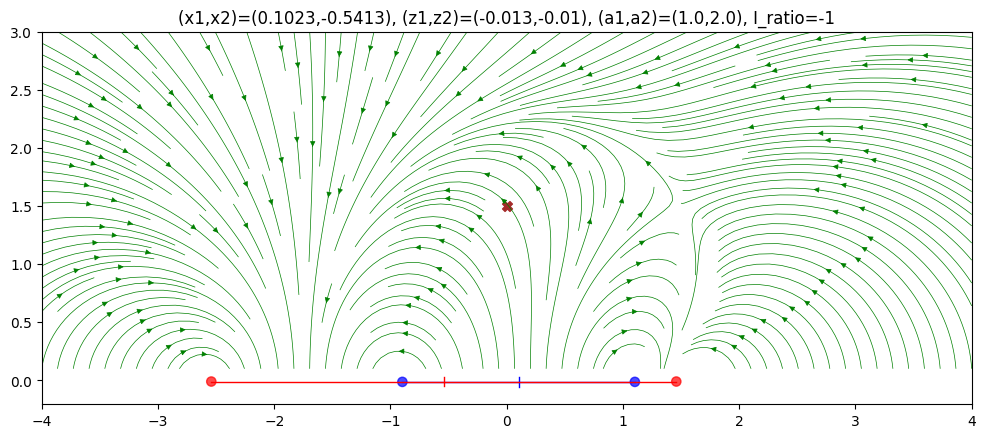

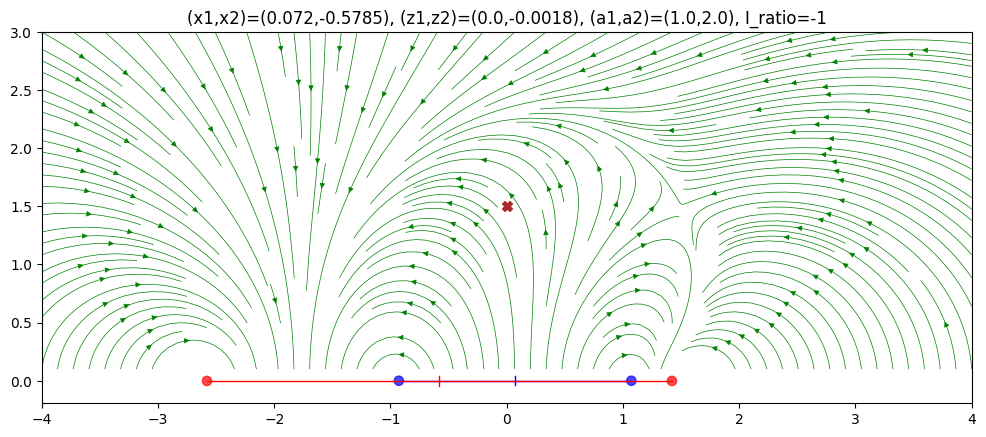

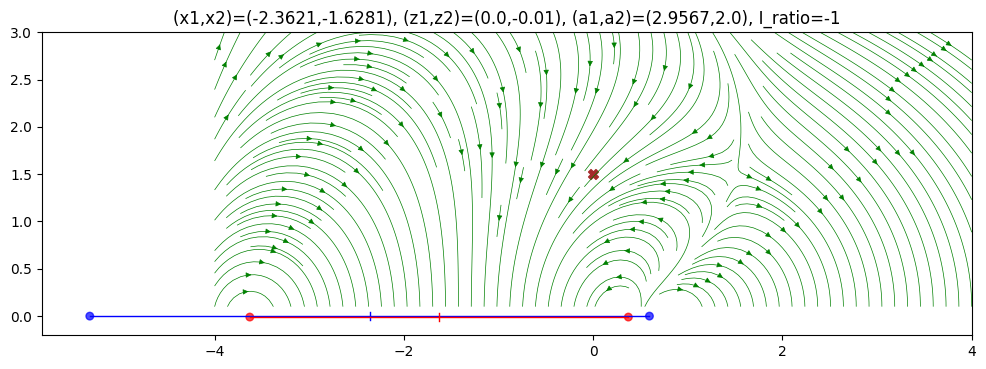

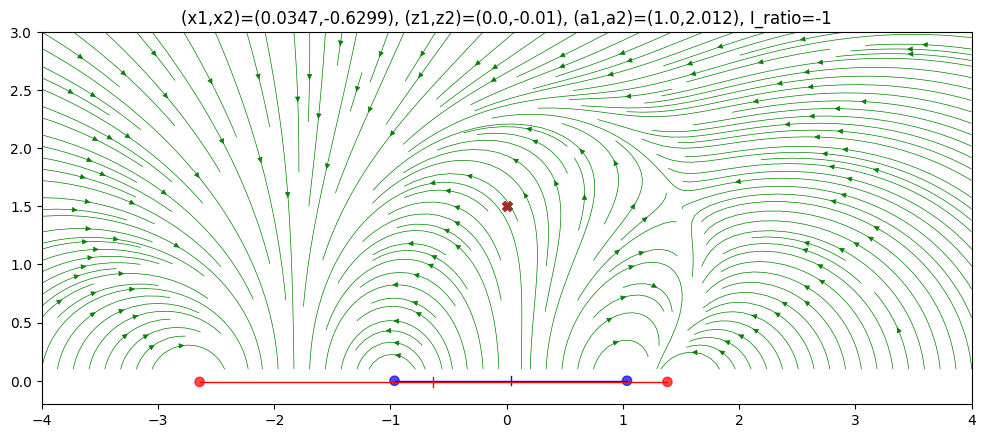

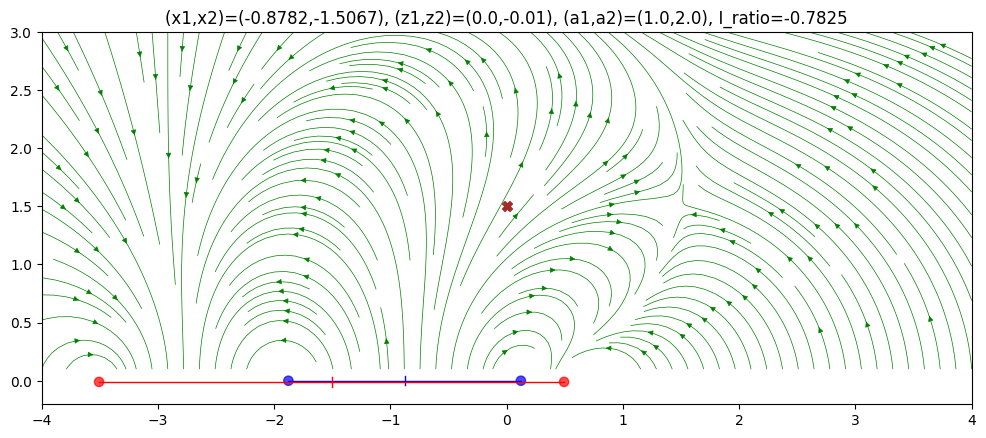

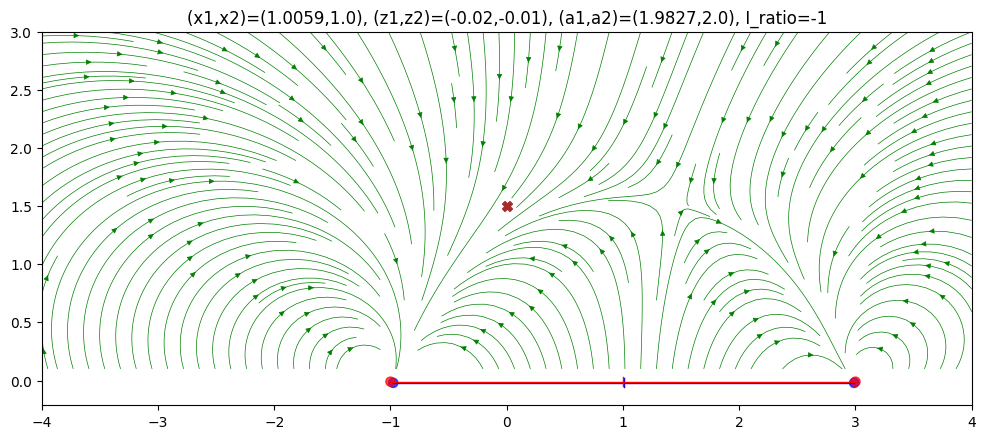

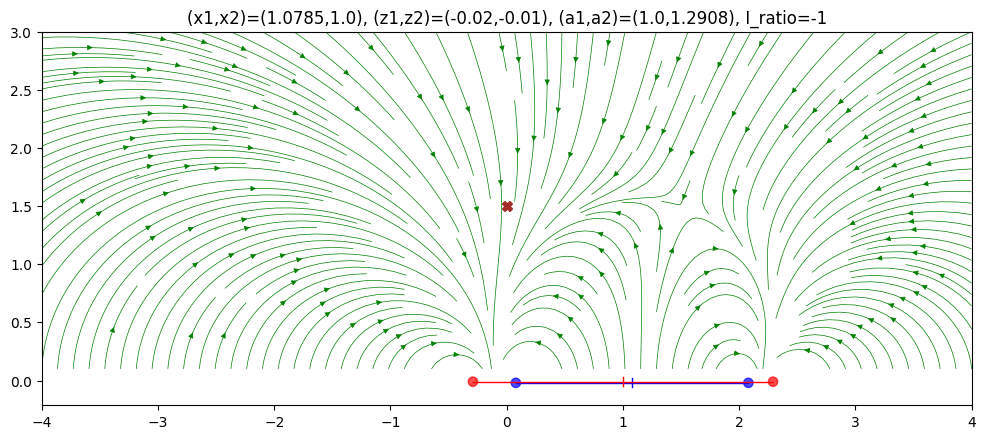

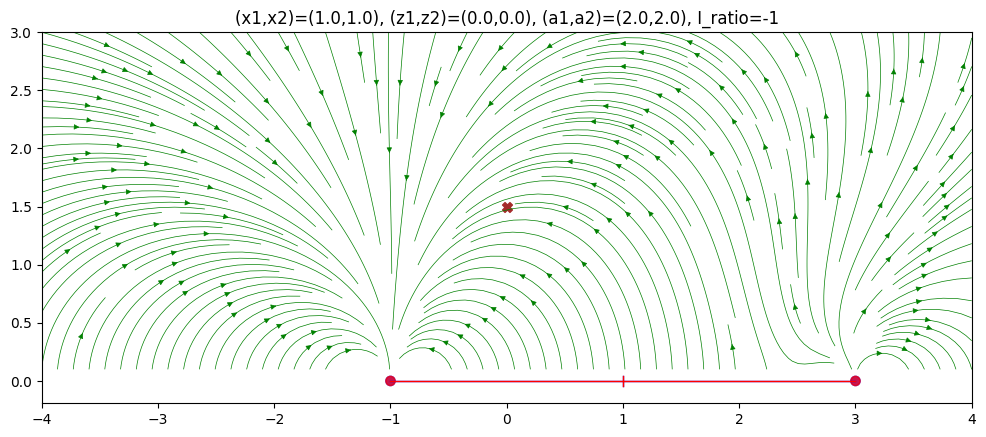

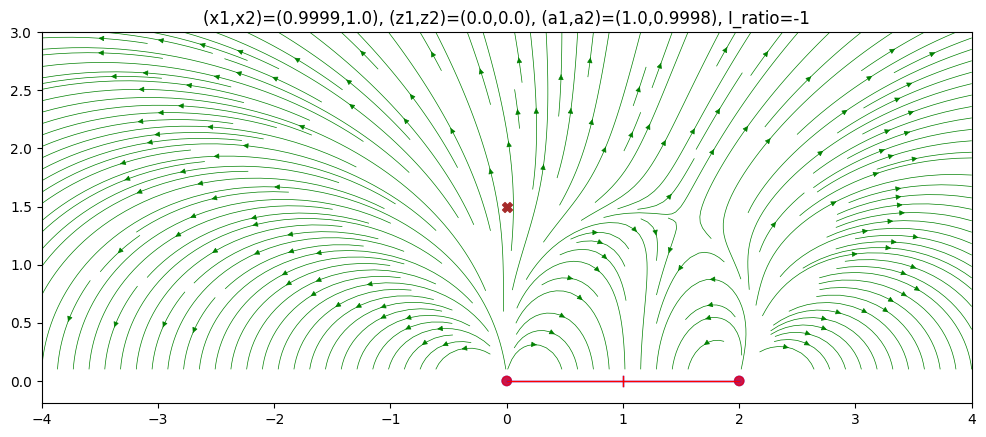

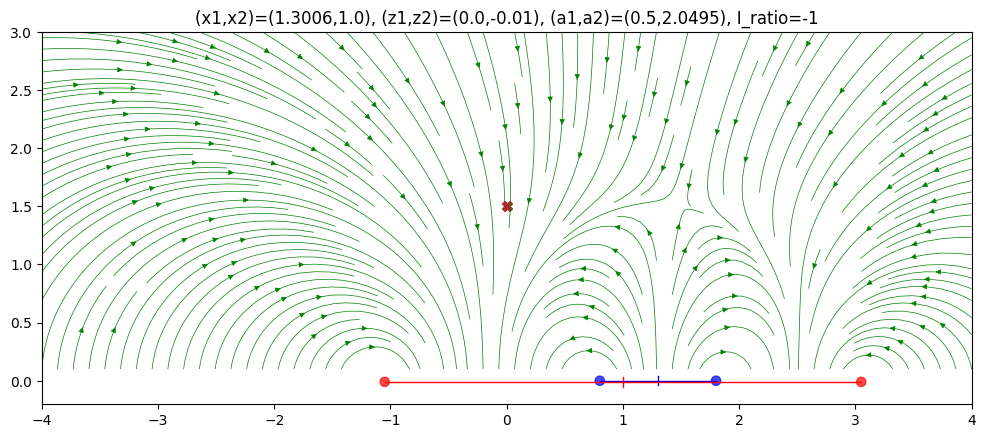

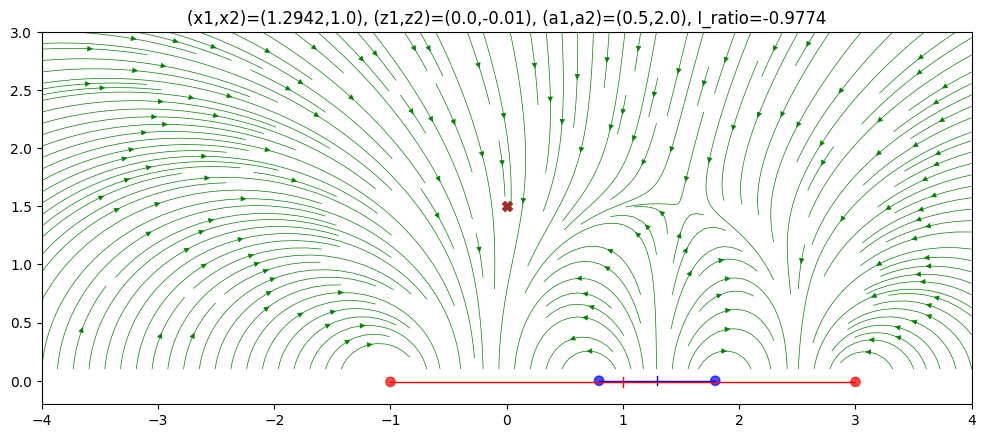

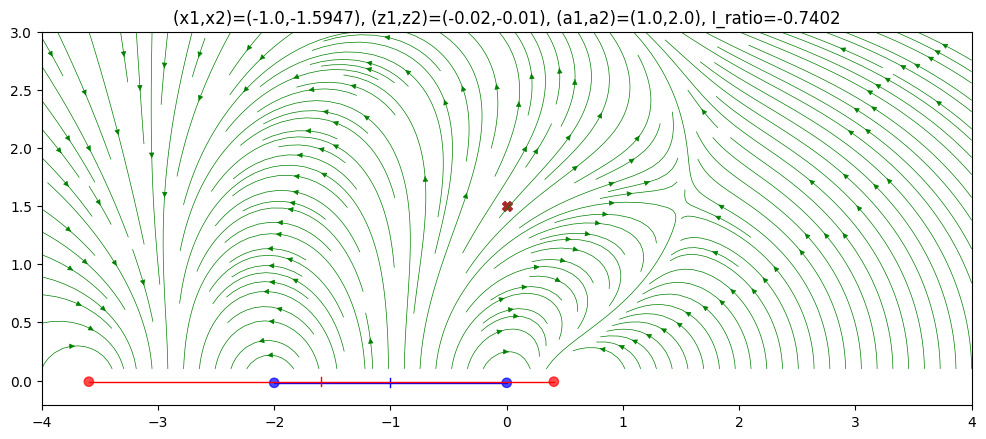

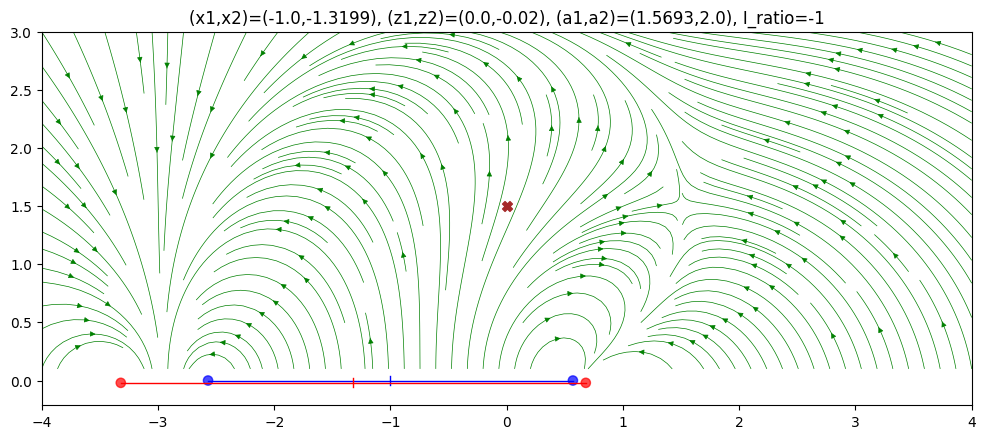

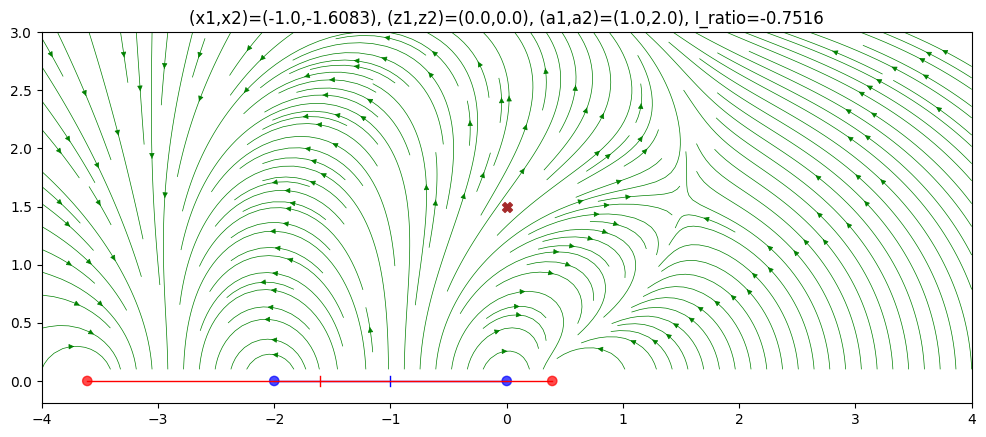

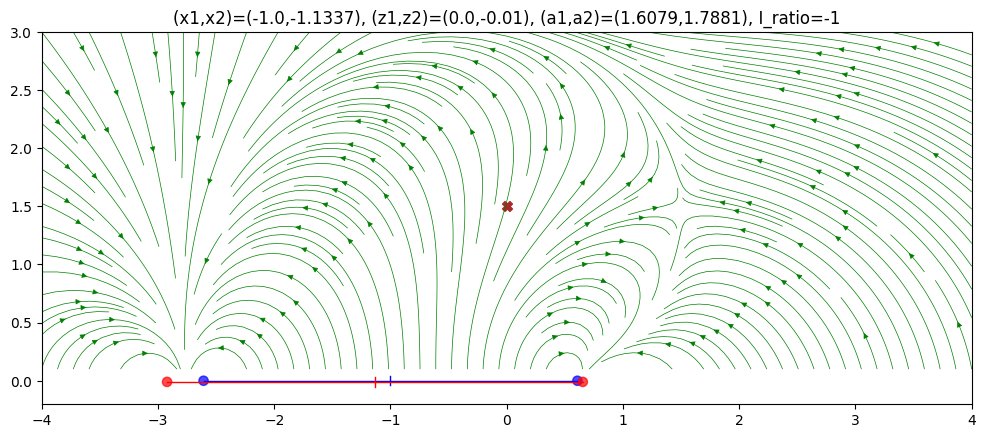

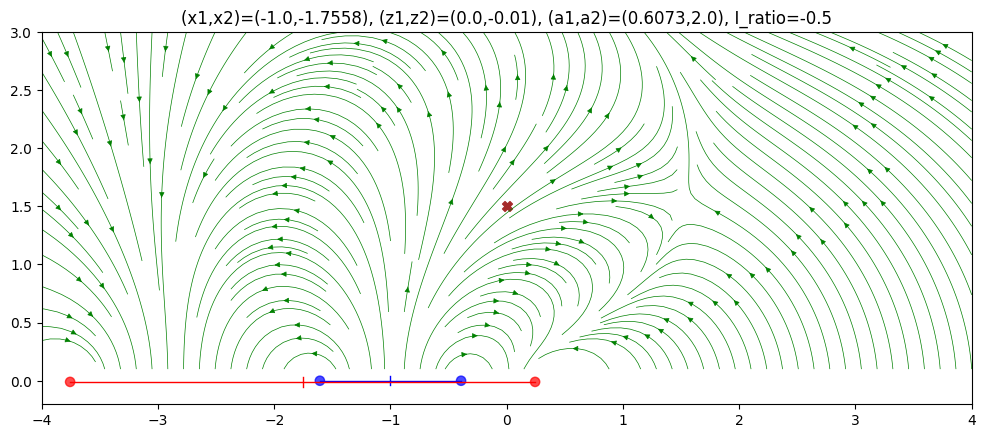

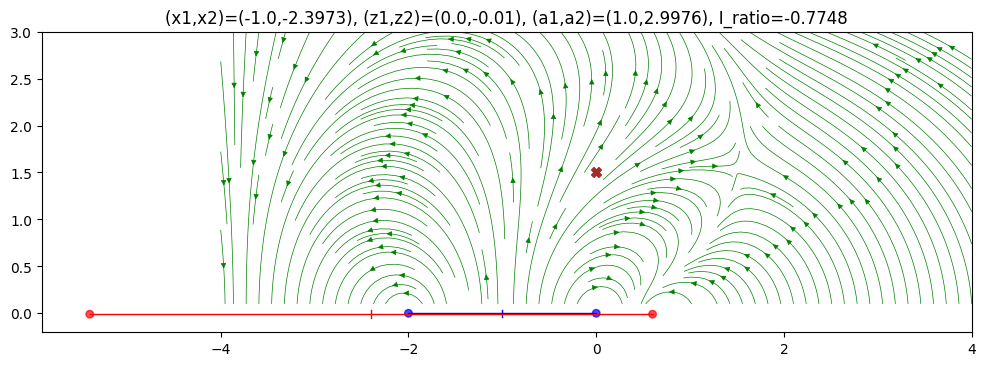

In [15]:
'''
Because of bounds, not all sets of vars can make zero B at the target point.
Make plots of magnetic field lines for successful results.
'''
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.lines as lines

def mark_loop(ax, x, z, a, color):
    '''
    visualize current loop
    '''
    r = 0.04
    ax.add_patch(Circle((x-a, z), r, color=color, alpha=0.7))
    ax.add_patch(Circle((x+a, z), r, color=color, alpha=0.7))
    ax.add_artist(lines.Line2D([x-a, x+a], [z, z], linewidth=1, color=color))
    ax.add_artist(lines.Line2D([x, x], [z-r, z+r], linewidth=1, color=color))

def plot_field(pp: Params, null_x, null_z):
    xmin, xmax = -4, 4
    zmin, zmax =  0.1, 3
    xx, zz = np.linspace(xmin, xmax, 150), np.linspace(zmin, zmax, 150)
    xx_grid, zz_grid = np.meshgrid(xx, zz)
    B = Bxz(xx_grid, zz_grid, pp.x1, pp.x2, pp.z1, pp.z2, pp.a1, pp.a2, 1, pp.I_ratio)
    # print(B)
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    mark_loop(ax, pp.x1, pp.z1, pp.a1, 'blue')
    mark_loop(ax, pp.x2, pp.z2, pp.a2, 'red')
    ax.scatter(null_x, null_z, s=50, color='brown', marker='X')
    ax.streamplot(xx_grid, zz_grid, B[0], B[1], density=2, color='g',
                    linewidth=0.5, cmap=plt.cm.viridis, arrowsize=0.8)
    ax.set_aspect('equal')
    ax.set_title(pp)
    plt.show()

for vars, result in zip(vars_tuples, results):
    if result.fun > 1e-6:
        continue
    pp = Params()
    for var, value in zip(vars, result.x):
        setattr(pp, var, value) # set pp.<var> = to best values saved in result.x
    plot_field(pp, null_x, null_z)